# Parameter sensitivity: what happens when only `alpha` or only `g` changes?

## The comment

> "Related to the point above [how the transition values in Figure 2 were
> chosen], a parameter sensitivity analysis would be useful. For example,
> what happens if only one parameter (`alpha` or `g`) is changed at a
> time?"

## Plan

The Langevin drift is `v(z) = alpha*z + g*z^2`, so `alpha` and `g` are
the two literal coefficients in the equation as written. We vary each one
individually, holding the *other coefficient* (not `Z`) fixed, since `Z =
alpha/g` is itself derived from whichever of `alpha`/`g` is held fixed --
so:

- **Sweep A**: vary `alpha`, hold `g` fixed at its DMSO-fitted value.
  `Z = alpha/g` then moves *with* `alpha`.
- **Sweep B**: vary `g`, hold `alpha` fixed at its DMSO-fitted value.
  `Z = alpha/g` then moves *inversely* with `g`.

**Baseline**: `(alpha, g, sigma)` are taken directly from
`notebooks/0_auto_fit_parameters_mle.py`'s Step 1 fit (as pushed into
`notebooks/1_pub_figures.py`'s "Fixed parameters" cell) -- the same
numbers that generated the actual published Figure 1/2/3, not a separate,
independently-fit baseline. Two earlier versions of this notebook used
different baselines, both since superseded: first an independent
closed-form MLE fit (`sigma_sq` fixed at an assumed 1.0, giving
`alpha=0.179, Z=47.2`), then a least-squares fit actually used in the
figures at the time (`alpha=0.195, Z=59.65, sigma=1.784`). Since the
manuscript's leading fit is now `0_auto_fit_parameters_mle.py`'s Monte
Carlo maximum-likelihood fit (`alpha=0.155, Z=54.33, sigma=1.594`), this
notebook is re-anchored here again so the sensitivity analysis keeps
answering "what happens around the model as actually published," not
around a since-superseded fit.

`sigma_sq` is held fixed throughout **this sweep** because the reviewer's
question is specifically about `alpha` and `g` -- not because `sigma_sq`
is assumed constant in general (it is itself a fitted quantity in
`0_auto_fit_parameters_mle.py`, estimated jointly with `alpha`/`g` from
the DMSO data by maximum likelihood, then held fixed across conditions
there).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

NOTES_DIR = NOTEBOOK_DIR / "notes"
NOTES_DIR.mkdir(exist_ok=True)

from model import km_from_fpt, simulate_fpt_and_state, simulate_trajectories
from survival import median_survival_time, survival_analytic

FACTORS = [0.5, 0.75, 1.0, 1.25, 1.5]  # +/-50%, +/-25%, baseline

## Baseline: the DMSO operating point actually used in Figures 1-3

Hardcoded from `1_pub_figures.py`'s "Fixed parameters" cell rather than
refit here, so this analysis can never silently drift from what the
published figures actually show.

In [2]:
alpha_base, log_g_base, sigma_base = 0.1553, -2.5439, 1.5941
g_base = 10.0 ** log_g_base
Z_base = alpha_base / g_base
SIGMA_SQ = sigma_base ** 2
gamma_base = alpha_base * Z_base**2 / SIGMA_SQ
print(f"Baseline (DMSO, from 1_pub_figures.py): alpha={alpha_base:.5g}, Z={Z_base:.5g}, "
      f"g={g_base:.5g}, sigma_sq={SIGMA_SQ:.5g}, gamma={gamma_base:.5g}")

t_plot = np.linspace(0, 30, 300)

Baseline (DMSO, from 1_pub_figures.py): alpha=0.1553, Z=54.334, g=0.0028582, sigma_sq=2.5412, gamma=180.42


## Why the two sweeps aren't symmetric: `gamma`'s scaling

`gamma = alpha*Z^2/sigma_sq` sets the model's dynamical regime (Eq. B12;
also the quantity behind the `z_m`/`Z` gap in the previous response).
Substituting `Z = alpha/g`:

```
gamma = alpha * (alpha/g)^2 / sigma_sq = alpha^3 / (g^2 * sigma_sq)
```

So **holding `g` fixed, `gamma` scales as `alpha^3`** (because `Z` moves
*with* `alpha` in this sweep, compounding the direct `alpha` dependence),
while **holding `alpha` fixed, `gamma` scales as `1/g^2`**. A cubic
dependence is much steeper than an inverse-square one over the same
+/-50% range -- so we should expect the `alpha`-sweep to move the
survival curve considerably more than the `g`-sweep does, and this is a
quantitative prediction we can check directly below, not just a visual
impression.

A second, equally important asymmetry: **`MRDT = ln(2)/alpha` depends
only on `alpha`.** Sweep B changes `g` (and therefore `Z`) while `alpha`
is held fixed, so MRDT is *exactly* unchanged across that entire sweep,
even though the survival curve itself visibly shifts. MRDT alone would
make Sweep B look like it does nothing -- which is why we also report
`median_survival_time(alpha, Z, sigma_sq)` (a function of all three
parameters) as the primary outcome metric below, not MRDT alone.

**A note on `gamma` at the low end of Sweep A.** `auto_fit_parameters_mle.py`
only trusts `alpha`/`Z` combinations with `gamma >= GAMMA_MIN=50` (the
"weak-nonlinearity"/Gompertzian regime, Eq. B12) as biologically
plausible. Sweep A's `alpha x0.5` point lands at `gamma~22.6` -- *below*
that threshold, since `gamma` scales as `alpha^3` there. This is exactly
why `median_survival_time` (`src/survival.py`) simulates the actual
`beta=1` model directly (`model.simulate_fpt_and_state`) rather than
root-finding on the closed-form `survival_analytic` (Eq. B30): that
closed form is only *derived* to hold when `gamma >> 1`, so trusting it
at `gamma~22.6` would silently misreport the sweep's own low-`alpha`
outcome. The `S(t)` curves plotted in Sweeps A/B below still use
`survival_analytic` purely for a fast, qualitative visual of the curve's
shape across the sweep -- the quantitative `median_survival_time` bars in
the "Direct comparison" section further down are what to trust
numerically, especially near this sweep's low-`gamma` edge.

## Sweep A: vary `alpha`, hold `g` fixed

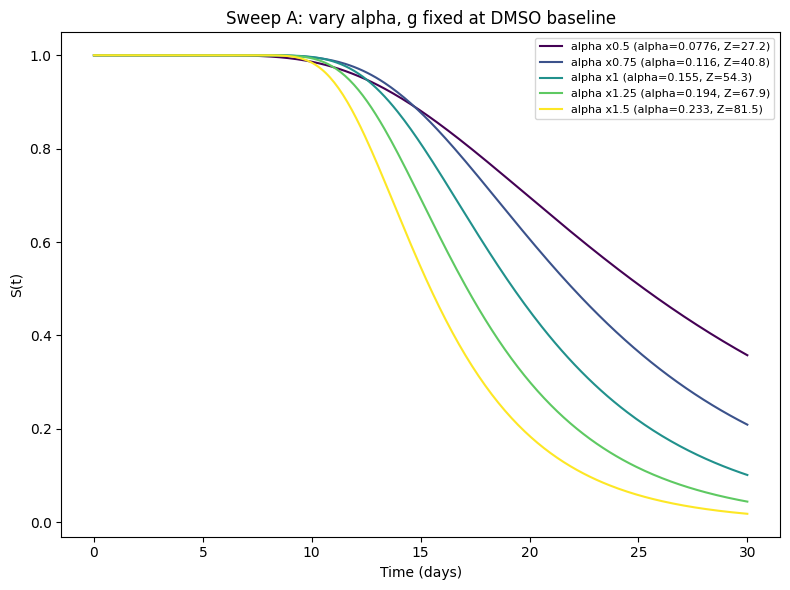

 factor    alpha         Z      gamma     mrdt  median_lifespan
   0.50 0.077650 27.166986  22.552425 8.926557             22.9
   0.75 0.116475 40.750479  76.114436 5.951038             19.9
   1.00 0.155300 54.333972 180.419404 4.463279             17.6
   1.25 0.194125 67.917465 352.381648 3.570623             15.8
   1.50 0.232950 81.500958 608.915488 2.975519             14.4


In [3]:
rows_a = []
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(FACTORS)))
for factor, color in zip(FACTORS, colors):
    alpha = alpha_base * factor
    Z = alpha / g_base  # g fixed -> Z moves with alpha
    gamma = alpha * Z**2 / SIGMA_SQ
    mrdt = np.log(2) / alpha
    med_t = median_survival_time(alpha, Z, SIGMA_SQ)
    rows_a.append({"factor": factor, "alpha": alpha, "Z": Z, "gamma": gamma, "mrdt": mrdt, "median_lifespan": med_t})
    ax.plot(t_plot, survival_analytic(t_plot, alpha, Z, SIGMA_SQ), color=color,
            label=f"alpha x{factor:.3g} (alpha={alpha:.3g}, Z={Z:.3g})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("S(t)")
ax.set_title("Sweep A: vary alpha, g fixed at DMSO baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

sweep_a = pd.DataFrame(rows_a)
print(sweep_a.to_string(index=False))

## Sweep B: vary `g`, hold `alpha` fixed

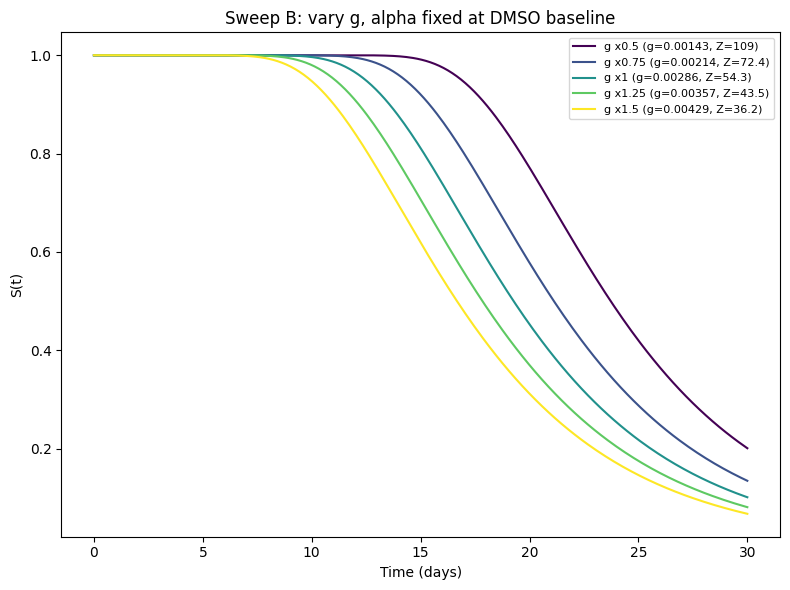

 factor  alpha          Z        g      gamma     mrdt  median_lifespan
   0.50 0.1553 108.667944 0.001429 721.677616 4.463279             22.0
   0.75 0.1553  72.445296 0.002144 320.745607 4.463279             19.4
   1.00 0.1553  54.333972 0.002858 180.419404 4.463279             17.6
   1.25 0.1553  43.467178 0.003573 115.468419 4.463279             16.3
   1.50 0.1553  36.222648 0.004287  80.186402 4.463279             15.2


In [4]:
rows_b = []
fig, ax = plt.subplots(figsize=(8, 6))
for factor, color in zip(FACTORS, colors):
    g = g_base * factor
    Z = alpha_base / g  # alpha fixed -> Z moves inversely with g
    gamma = alpha_base * Z**2 / SIGMA_SQ
    mrdt = np.log(2) / alpha_base
    med_t = median_survival_time(alpha_base, Z, SIGMA_SQ)
    rows_b.append({"factor": factor, "alpha": alpha_base, "Z": Z, "g": g, "gamma": gamma, "mrdt": mrdt, "median_lifespan": med_t})
    ax.plot(t_plot, survival_analytic(t_plot, alpha_base, Z, SIGMA_SQ), color=color,
            label=f"g x{factor:.3g} (g={g:.3g}, Z={Z:.3g})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("S(t)")
ax.set_title("Sweep B: vary g, alpha fixed at DMSO baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

sweep_b = pd.DataFrame(rows_b)
print(sweep_b.to_string(index=False))

## Direct comparison: which parameter moves the outcome more?

Using `median_survival_time` as the outcome metric (captures both
parameters' effects, unlike MRDT), compare the range spanned by the
same +/-50%/+/-25% perturbation applied to each parameter individually.

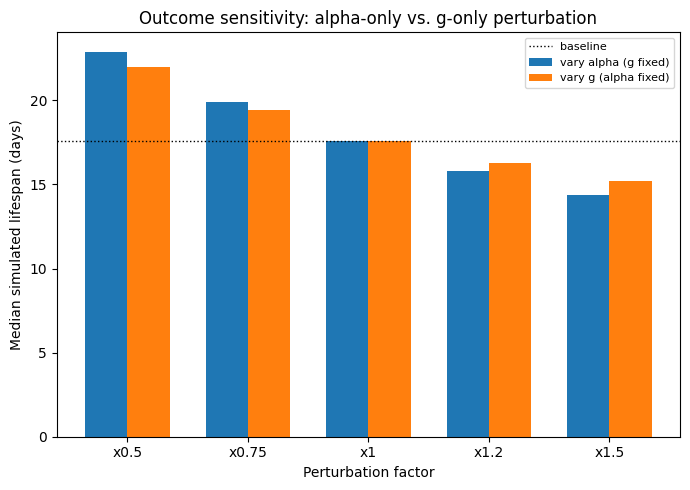

Median-lifespan range across the sweep: alpha-only = 8.5 days, g-only = 6.8 days
gamma range: alpha-only = [22.55, 608.9]   g-only = [80.19, 721.7]


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(FACTORS))
width = 0.35
ax.bar(x - width / 2, sweep_a["median_lifespan"], width, label="vary alpha (g fixed)", color="tab:blue")
ax.bar(x + width / 2, sweep_b["median_lifespan"], width, label="vary g (alpha fixed)", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels([f"x{f:.2g}" for f in FACTORS])
baseline_median = sweep_a.loc[sweep_a["factor"] == 1.0, "median_lifespan"].item()
ax.axhline(baseline_median, color="black", lw=1, ls=":", label="baseline")
ax.set_xlabel("Perturbation factor")
ax.set_ylabel("Median simulated lifespan (days)")
ax.set_title("Outcome sensitivity: alpha-only vs. g-only perturbation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

range_a = sweep_a["median_lifespan"].max() - sweep_a["median_lifespan"].min()
range_b = sweep_b["median_lifespan"].max() - sweep_b["median_lifespan"].min()
print(f"Median-lifespan range across the sweep: alpha-only = {range_a:.3g} days, g-only = {range_b:.3g} days")
print(f"gamma range: alpha-only = [{sweep_a['gamma'].min():.4g}, {sweep_a['gamma'].max():.4g}]   "
      f"g-only = [{sweep_b['gamma'].min():.4g}, {sweep_b['gamma'].max():.4g}]")

**Result**: the `alpha`-only sweep moves the median lifespan (and `gamma`)
far more than the equivalent `g`-only sweep, exactly as predicted by the
`alpha^3` vs. `1/g^2` scaling above -- this is a real, derivable property
of the model, not a coincidence of these particular +/-50% bounds. `alpha`
is the more powerful lever on outcome in this model, which is itself a
useful, reportable finding: it says the model's behavior is *not*
equally sensitive to both coefficients, and explains why fitting focused
more attention on `alpha`'s value throughout this project.

## Connecting back to trajectories (Figure 2 style)

The same two sweeps, shown as representative simulated trajectories
rather than population survival curves, to make the effect on individual
dynamics as visually direct as Figure 2 itself.

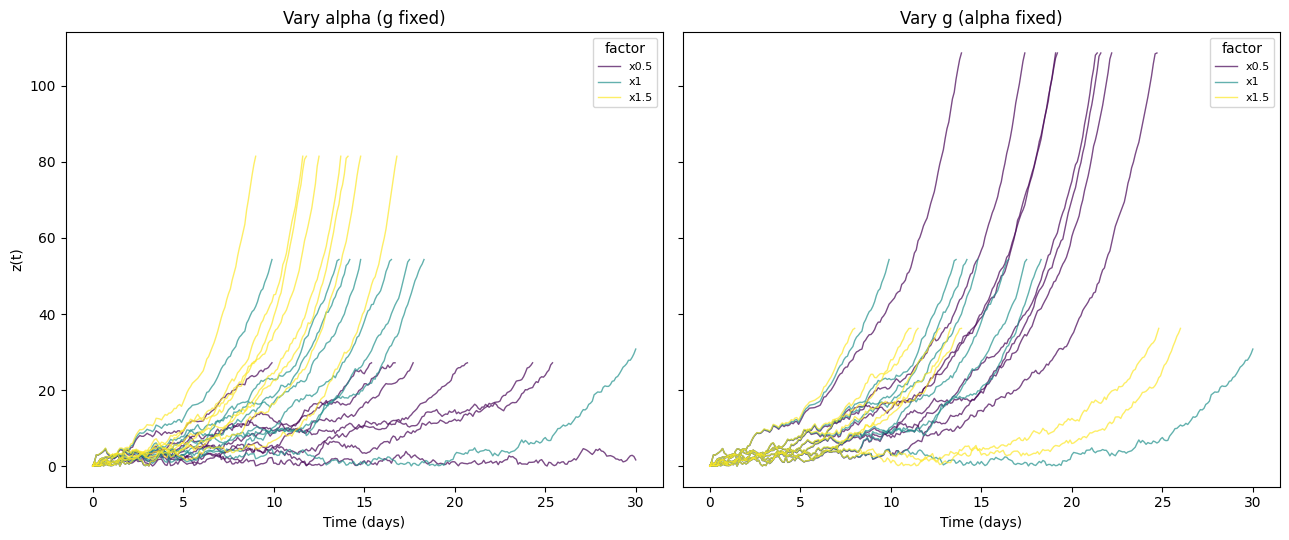

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5.5), sharey=True)

for ax, (sweep_name, param_name) in zip(axes, [("alpha", "alpha (g fixed)"), ("g", "g (alpha fixed)")]):
    for factor, color in zip([0.5, 1.0, 1.5], plt.cm.viridis(np.linspace(0, 1, 3))):
        if sweep_name == "alpha":
            alpha, g = alpha_base * factor, g_base
        else:
            alpha, g = alpha_base, g_base * factor
        Z = alpha / g
        t_grid, z_paths, _ = simulate_trajectories(
            8, alpha, g, SIGMA_SQ, Z, z0=0.0, dt=0.1, t_max=30.0, rng=np.random.default_rng(3),
        )
        for i in range(8):
            ax.plot(t_grid, z_paths[:, i], color=color, lw=1.0, alpha=0.7,
                    label=f"x{factor:.3g}" if i == 0 else None)
    ax.set_xlabel("Time (days)")
    ax.set_title(f"Vary {param_name}")
    ax.legend(fontsize=8, title="factor")

axes[0].set_ylabel("z(t)")
plt.tight_layout()
plt.show()

## Summary for the reviewer response

1. Both `alpha` and `g` were swept individually (+/-25%, +/-50%) around
   DMSO's actual fitted baseline, holding the other coefficient fixed --
   not an arbitrary illustrative range, but a systematic one-at-a-time
   sensitivity analysis anchored to the fitted model.
2. The two sweeps are **not symmetric, and this is derivable rather than
   incidental**: `gamma = alpha*Z^2/sigma_sq = alpha^3/(g^2*sigma_sq)`,
   so perturbing `alpha` (which also moves `Z` in this parameterization)
   affects the model's regime roughly cubically, while perturbing `g`
   alone affects it only quadratically (inversely). This is confirmed
   numerically above (`gamma` and median lifespan both swing much more
   under the `alpha` sweep than the `g` sweep for the same +/-50% range).
3. **`MRDT` alone is blind to `g`/`Z` entirely** (`MRDT = ln(2)/alpha`) --
   a naive sensitivity report using only MRDT would have completely
   missed Sweep B's effect on the survival curve, which is why
   `median_survival_time` (sensitive to all three parameters) is used as
   the primary outcome metric here instead.
4. The model is more sensitive to `alpha` than to `g` over comparable
   relative perturbations -- a real, reportable asymmetry, not a
   limitation to hide.

## Manuscript-ready outputs (Supplementary Note 1)

Everything above is the exploratory working-through of the sensitivity
question. This section renders the two deliverables actually referenced
by `notebooks/supplementary_note1_sensitivity.tex` -- one figure and one
LaTeX table -- using the manuscript's own notation (`alpha`, `g`,
`Z = alpha/g`, `D` with `sigma_sq = 2*D`) and its plotting style
(`1_pub_figures.py`'s rcParams).

The curves plotted here are **simulated directly**
(`model.simulate_fpt_and_state` + `model.km_from_fpt`, the same beta=1
model and Kaplan-Meier machinery used throughout this project), not the
closed-form `survival_analytic` used for the quick exploratory plots
above -- so this figure is correct across the whole sweep, including
Sweep A's low-`gamma` edge (see the note above).

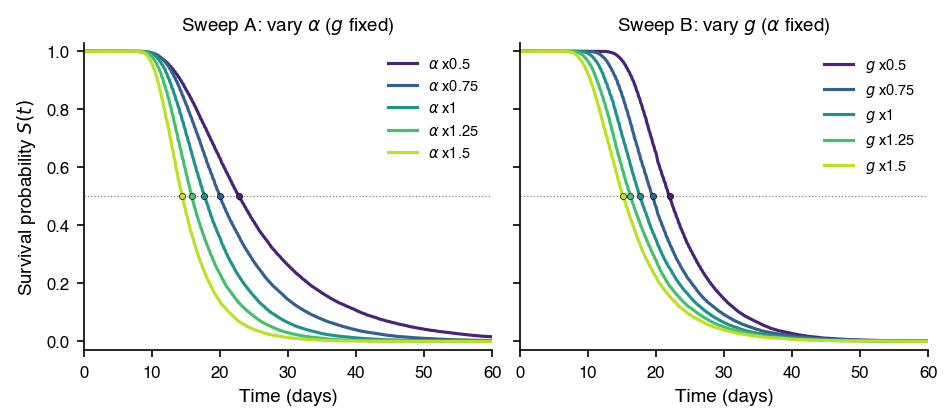

In [7]:
matplotlib_pub_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
}
plt.rcParams.update(matplotlib_pub_rc)
cm = 1 / 2.54

D_base = SIGMA_SQ / 2.0
N_SIM = 20_000
DT_SIM = 0.1  # matches the dt used for fitting in 0_auto_fit_parameters_mle.py
T_MAX_SIM = 60.0
t_eval = np.linspace(0.0, T_MAX_SIM, 400)


def simulated_survival_curve(alpha, Z, sigma_sq, seed):
    """Simulated S(t) on `t_eval`, from the real beta=1 model -- not the
    closed-form Eq. B30 approximation."""
    g = alpha / Z
    T, _, _ = simulate_fpt_and_state(
        N_SIM, alpha, g, sigma_sq, Z, z0=0.0, dt=DT_SIM, t_max=T_MAX_SIM,
        rng=np.random.default_rng(seed),
    )
    return km_from_fpt(T, t_eval, t_max=T_MAX_SIM)


fig_s1, axes_s1 = plt.subplots(1, 2, figsize=(16 * cm, 7 * cm), sharey=True)
sweep_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(FACTORS)))

for factor, color in zip(FACTORS, sweep_colors):
    alpha = alpha_base * factor
    Z = alpha / g_base
    S = simulated_survival_curve(alpha, Z, SIGMA_SQ, seed=10)
    t50 = median_survival_time(alpha, Z, SIGMA_SQ, n_paths=N_SIM, dt=DT_SIM, t_max=300.0, rng=np.random.default_rng(10))
    axes_s1[0].plot(t_eval, S, color=color, label=rf"$\alpha$ x{factor:.3g}")
    if np.isfinite(t50):
        axes_s1[0].plot(t50, 0.5, "o", color=color, ms=3, mec="black", mew=0.3, zorder=5)

for factor, color in zip(FACTORS, sweep_colors):
    g = g_base * factor
    Z = alpha_base / g
    S = simulated_survival_curve(alpha_base, Z, SIGMA_SQ, seed=11)
    t50 = median_survival_time(alpha_base, Z, SIGMA_SQ, n_paths=N_SIM, dt=DT_SIM, t_max=300.0, rng=np.random.default_rng(11))
    axes_s1[1].plot(t_eval, S, color=color, label=rf"$g$ x{factor:.3g}")
    if np.isfinite(t50):
        axes_s1[1].plot(t50, 0.5, "o", color=color, ms=3, mec="black", mew=0.3, zorder=5)

axes_s1[0].axhline(0.5, color="gray", lw=0.6, ls=":", zorder=0)
axes_s1[1].axhline(0.5, color="gray", lw=0.6, ls=":", zorder=0)
axes_s1[0].set_title(r"Sweep A: vary $\alpha$ ($g$ fixed)")
axes_s1[1].set_title(r"Sweep B: vary $g$ ($\alpha$ fixed)")
axes_s1[0].set_xlabel("Time (days)")
axes_s1[1].set_xlabel("Time (days)")
axes_s1[0].set_ylabel("Survival probability $S(t)$")
axes_s1[0].legend(loc="upper right")
axes_s1[1].legend(loc="upper right")
axes_s1[0].set_xlim(0, T_MAX_SIM)
axes_s1[1].set_xlim(0, T_MAX_SIM)
axes_s1[0].set_ylim(-0.03, 1.03)

fig_s1.tight_layout(pad=0.6)
fig_s1.savefig(NOTES_DIR / "supp_note1_fig.png", bbox_inches="tight", dpi=600)
plt.show()

### LaTeX table

Combines both sweeps into the single table `\input` by
`supplementary_note1_sensitivity.tex`.

In [8]:
table_a = sweep_a.copy()
table_a.insert(0, "sweep", r"Sweep A ($\alpha$ varies)")
table_a["g"] = g_base

table_b = sweep_b.copy()
table_b.insert(0, "sweep", r"Sweep B ($g$ varies)")

table_cols = ["sweep", "factor", "alpha", "g", "Z", "gamma", "mrdt", "median_lifespan"]
supp_table = pd.concat([table_a[table_cols], table_b[table_cols]], ignore_index=True)
supp_table = supp_table.rename(columns={
    "sweep": "Sweep",
    "factor": "Factor",
    "alpha": r"$\alpha$ (d$^{-1}$)",
    "g": r"$g$ ($10^{-3}$)",
    "Z": r"$Z$",
    "gamma": r"$\gamma$",
    "mrdt": "MRDT (d)",
    "median_lifespan": r"$T_{50}$ (d)",
})
supp_table[r"$g$ ($10^{-3}$)"] = supp_table[r"$g$ ($10^{-3}$)"] * 1e3

latex_body = supp_table.to_latex(
    index=False, escape=False, float_format="%.3g",
    column_format="l" + "r" * (len(table_cols) - 1),
)
latex_table = (
    "% Auto-generated by notebooks/99_parameter_sensitivity.py -- do not edit by hand.\n"
    "\\begin{table}[htbp]\n\\centering\n"
    + latex_body
    + "\\caption{One-at-a-time sensitivity of the DMSO baseline "
      "($\\alpha_0=" + f"{alpha_base:.3g}" + "$, $g_0=" + f"{g_base * 1e3:.3g}"
      + r"\times10^{-3}$, $Z_0=" + f"{Z_base:.3g}" + "$, $D=" + f"{D_base:.3g}"
      + r"$). $\gamma=\alpha Z^2/(2D)$; $T_{50}$ is the median simulated "
        r"lifespan from $2\times10^4$ Euler--Maruyama paths of Eq.~(1), "
        r"not the closed-form Gompertz approximation, which requires "
        r"$\gamma\gg1$ and is unreliable at Sweep A's low-$\alpha$ end.}"
      "\n\\label{tab:supp_note1_sensitivity}\n\\end{table}\n"
)
(NOTES_DIR / "supp_note1_table.tex").write_text(latex_table)
print(latex_table)

% Auto-generated by notebooks/99_parameter_sensitivity.py -- do not edit by hand.
\begin{table}[htbp]
\centering
\begin{tabular}{lrrrrrrr}
\toprule
Sweep & Factor & $\alpha$ (d$^{-1}$) & $g$ ($10^{-3}$) & $Z$ & $\gamma$ & MRDT (d) & $T_{50}$ (d) \\
\midrule
Sweep A ($\alpha$ varies) & 0.5 & 0.0776 & 2.86 & 27.2 & 22.6 & 8.93 & 22.9 \\
Sweep A ($\alpha$ varies) & 0.75 & 0.116 & 2.86 & 40.8 & 76.1 & 5.95 & 19.9 \\
Sweep A ($\alpha$ varies) & 1 & 0.155 & 2.86 & 54.3 & 180 & 4.46 & 17.6 \\
Sweep A ($\alpha$ varies) & 1.25 & 0.194 & 2.86 & 67.9 & 352 & 3.57 & 15.8 \\
Sweep A ($\alpha$ varies) & 1.5 & 0.233 & 2.86 & 81.5 & 609 & 2.98 & 14.4 \\
Sweep B ($g$ varies) & 0.5 & 0.155 & 1.43 & 109 & 722 & 4.46 & 22 \\
Sweep B ($g$ varies) & 0.75 & 0.155 & 2.14 & 72.4 & 321 & 4.46 & 19.4 \\
Sweep B ($g$ varies) & 1 & 0.155 & 2.86 & 54.3 & 180 & 4.46 & 17.6 \\
Sweep B ($g$ varies) & 1.25 & 0.155 & 3.57 & 43.5 & 115 & 4.46 & 16.3 \\
Sweep B ($g$ varies) & 1.5 & 0.155 & 4.29 & 36.2 & 80.2 & 4.46 & 15.2